In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

In [40]:
df = pd.read_csv("Heart_Disease_Dataset.csv")
df.columns = df.columns.str.strip()

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [41]:
# Check columns first
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'source'],
      dtype='object')


In [42]:
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'source']


In [43]:
# Drop source if exists
if 'source' in df.columns:
    df.drop('source', axis=1, inplace=True)

df.rename(columns={'num': 'target'}, inplace=True)
df['target'].value_counts()

,count
target,
0,411
1,265
2,109
3,107
4,28


In [44]:
X = df.drop('target', axis=1)
y = df['target']

In [45]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [46]:
print(X.shape)

(920, 18)


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        82
           1       0.50      0.55      0.52        53
           2       0.30      0.14      0.19        22
           3       0.15      0.19      0.17        21
           4       0.00      0.00      0.00         6

    accuracy                           0.58       184
   macro avg       0.35      0.35      0.34       184
weighted avg       0.54      0.58      0.56       184


Random Forest
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        82
           1       0.53      0.58      0.56        53
           2       0.06      0.05      0.05        22
           3       0.06      0.05      0.05        21
           4       0.00      0.00      0.00         6

    accuracy                           0.57       184
   macro avg       0.29      0.31      0.30       184
weighted avg       0.52      0.57      0.

In [51]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [52]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [53]:
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test)

roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7847866428744279


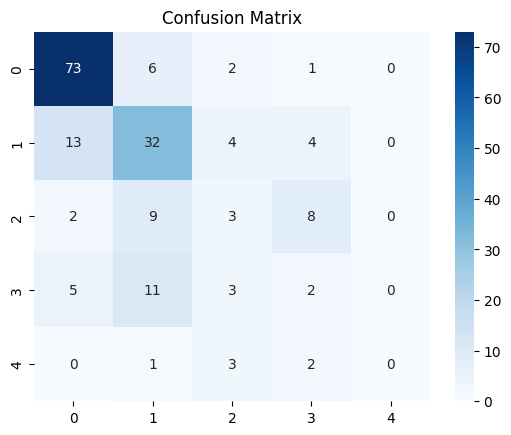

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

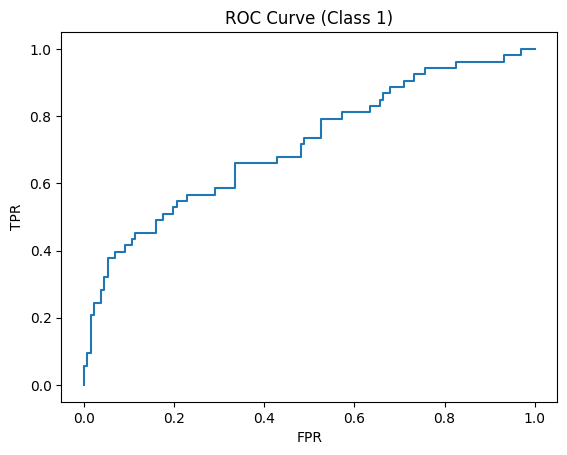

In [57]:
from sklearn.preprocessing import label_binarize

# Convert to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])

y_prob = model.predict_proba(X_test)

# Plot ROC for one class (example: class 1)
fpr, tpr, _ = roc_curve(y_test_bin[:,1], y_prob[:,1])

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Class 1)")
plt.show()

In [61]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        82
           1       0.51      0.53      0.52        53
           2       0.35      0.32      0.33        22
           3       0.08      0.10      0.09        21
           4       0.00      0.00      0.00         6

    accuracy                           0.56       184
   macro avg       0.35      0.35      0.35       184
weighted avg       0.56      0.56      0.56       184



In [62]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X, y, cv=5, scoring='f1')

print("F1 Scores:", scores)
print("Mean F1:", scores.mean())

F1 Scores: [nan nan nan nan nan]
Mean F1: nan


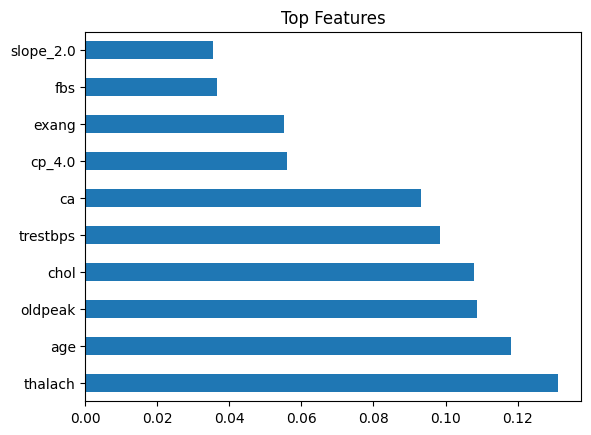

In [63]:
import pandas as pd

feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

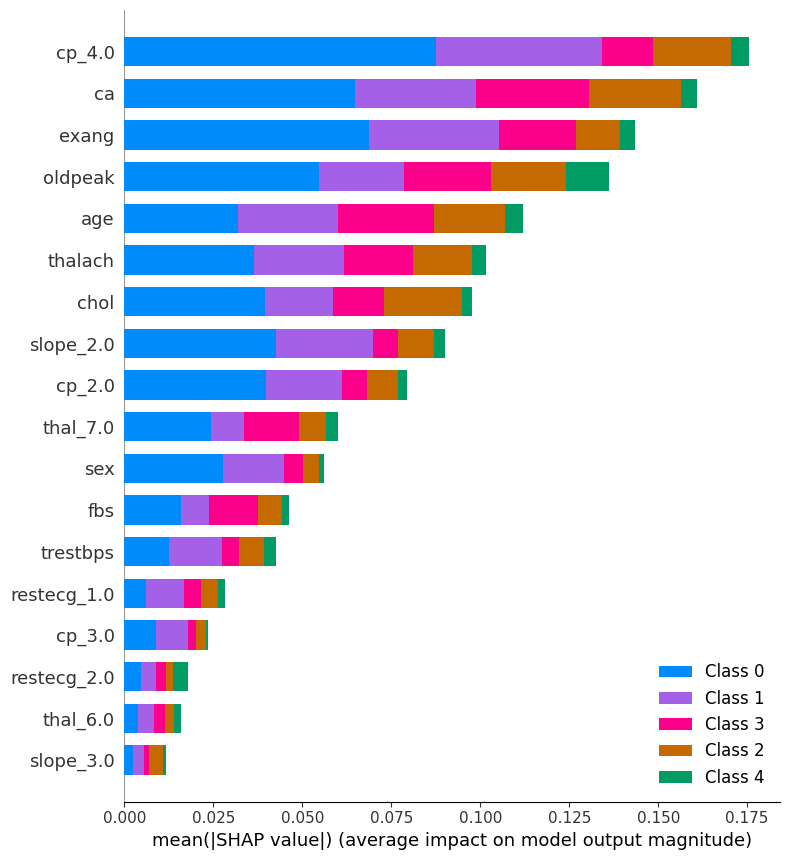

In [64]:
import shap

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [65]:
import joblib

joblib.dump(best_model, "heart_model.pkl")
joblib.dump(scaler, "heart_scaler.pkl")
joblib.dump(imputer, "heart_imputer.pkl")

['heart_imputer.pkl']

In [66]:
import pickle

# Save model
with open("Heart.pkl", "wb") as file:
    pickle.dump(model, file)

In [67]:
from google.colab import files

files.download("Heart.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>